# Energy Generation Forecasting with LSTM

This notebook implements a Long Short-Term Memory (LSTM) neural network to forecast daily electricity generation for the **Valparaíso region** of Chile, using historical data from 2016 to 2023.

**Experimental design**

| Split | Period | Purpose |
|---|---|---|
| Training | 2016 – 2021 | Model fitting |
| Validation | 2022 | Hyperparameter selection (Optuna) |
| Test | 2023 | Held-out evaluation |

Hyperparameters were selected via Optuna Bayesian optimization. Model performance on the held-out test set is reported in Section 6.

> **Note:** This notebook is a reproducible toy case for a single region. The dataset (`generacion_total.parquet`) must be present one level above this directory.

## 1. Import Libraries

All dependencies are imported upfront. The key libraries are PyTorch (LSTM model), Optuna (hyperparameter optimization), and scikit-learn (preprocessing and metrics).

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import optuna

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Suppress Optuna trial-level logs for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)
# With num_layers=1, PyTorch LSTM ignores the dropout parameter (it only applies
# between stacked layers). This suppresses the resulting UserWarning.
warnings.filterwarnings("ignore", "dropout option", UserWarning)

# Seed for reproducibility
SEED = 99
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs("figures", exist_ok=True)

c:\Users\felip\OneDrive\Escritorio\Proyecto de programacion\Tesis_optimizacion_energetica\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading & Preprocessing

The raw dataset contains hourly generation records per power plant across all Chilean regions. We aggregate to **daily totals** and restrict to the **Valparaíso region** for this case study.

In [2]:
# Load consolidated national generation dataset
df = pd.read_parquet("data/generacion_total.parquet")

# Filter for Valparaíso region
df = df[df["REGIÓN"] == "Región de Valparaíso"]

# Aggregate all plants to daily total generation
df = df.groupby("FECHA")["TOTAL"].sum().reset_index()

# Restrict to 2016–2023 (sufficient history, avoids structural breaks in early years)
df = df[(df["FECHA"] > "2016-01-01") & (df["FECHA"] < "2024-01-01")]
df.set_index("FECHA", inplace=True)

print(f"Dataset: {len(df)} daily records  |  {df.index.min().date()} → {df.index.max().date()}")
print(f"Generation range: {df['TOTAL'].min():,.0f} – {df['TOTAL'].max():,.0f} MWh/day")
df.head()

Dataset: 2890 daily records  |  2016-01-02 → 2023-11-30
Generation range: 5,889 – 62,259 MWh/day


,TOTAL
FECHA,
2016-01-02,26149.76
2016-01-03,21894.68
2016-01-04,28286.79
2016-01-05,32926.36
2016-01-06,38039.08


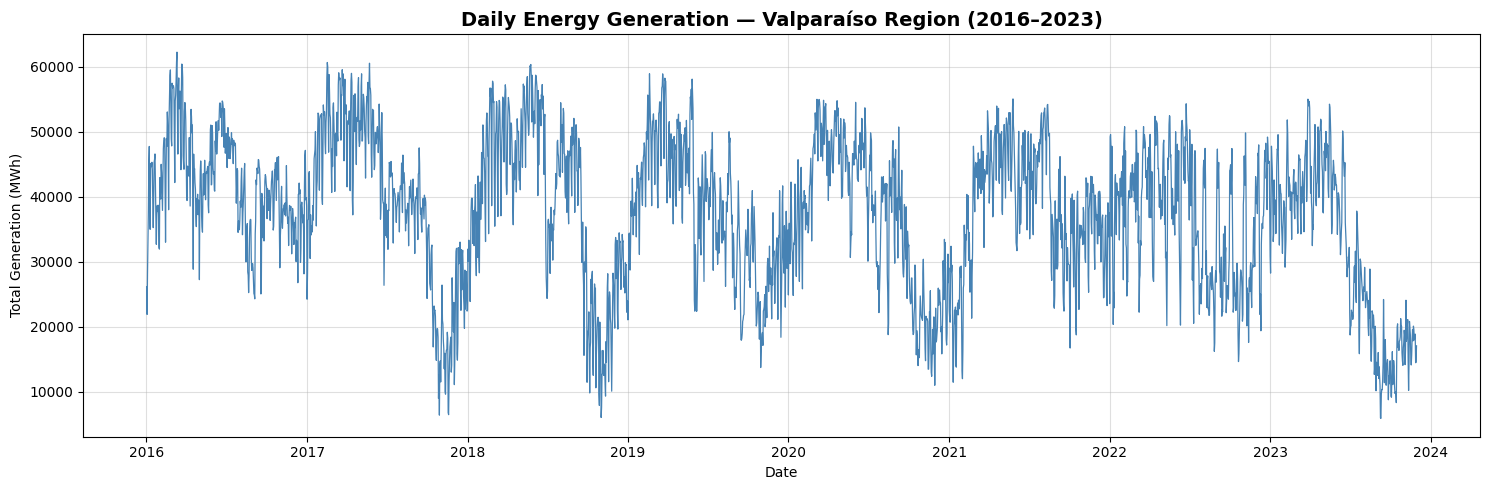

In [3]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df["TOTAL"], linewidth=0.9, color="steelblue")
plt.title("Daily Energy Generation — Valparaíso Region (2016–2023)", fontsize=14, weight="bold")
plt.xlabel("Date")
plt.ylabel("Total Generation (MWh)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/01_generation_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.1 Normalization and Sequence Creation

We standardize the series using **z-score normalization** (StandardScaler), fitting the scaler exclusively on training data to prevent data leakage into the validation and test sets.

We then construct **sliding window sequences** of length 30 days: each sample contains 30 consecutive days as input and the next day as the target. The 30-day window was determined via Optuna hyperparameter search as reported in the paper.

In [4]:
SEQUENCE_LENGTH = 30  # look-back window in days (paper Section 4.2)
BATCH_SIZE      = 32

# Split by year first — scaler must be fit on training data only to avoid leakage
train_raw = df[df.index.year <= 2021][["TOTAL"]].values
val_raw   = df[df.index.year == 2022][["TOTAL"]].values
test_raw  = df[df.index.year == 2023][["TOTAL"]].values

# z-score normalization: fit on train, apply to all splits
scaler     = StandardScaler()
train_data = scaler.fit_transform(train_raw)
val_data   = scaler.transform(val_raw)
test_data  = scaler.transform(test_raw)

def create_sequences(data, seq_len):
    """Convert a 1-D array into (X, y) sliding-window pairs."""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_val,   y_val   = create_sequences(val_data,   SEQUENCE_LENGTH)
X_test,  y_test  = create_sequences(test_data,  SEQUENCE_LENGTH)

# Convert to PyTorch tensors
to_t = lambda a: torch.tensor(a, dtype=torch.float32)
X_train, y_train = to_t(X_train), to_t(y_train)
X_val,   y_val   = to_t(X_val),   to_t(y_val)
X_test,  y_test  = to_t(X_test),  to_t(y_test)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE)

print(f"Train sequences : {len(X_train):>5}")
print(f"Val sequences   : {len(X_val):>5}")
print(f"Test sequences  : {len(X_test):>5}")

Train sequences :  2161
Val sequences   :   335
Test sequences  :   304


## 3. Model Architecture

We use a stacked LSTM followed by a fully-connected layer. The model takes a sequence of `SEQUENCE_LENGTH` standardized generation values and outputs the prediction for the next day.

```
Input  (batch, 30, 1)
  └─► LSTM(hidden, num_layers)
        └─► last hidden state  (batch, hidden)
              └─► Linear → Output (batch, 1)
```

In [5]:
class EnergyLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # use last time-step output

## 4. Hyperparameter Optimization

We use **Optuna** with TPE (Tree-structured Parzen Estimator) to search over:

| Hyperparameter | Search range |
|---|---|
| `hidden_size` | 32 – 256 |
| `num_layers` | 1 – 4 |
| `dropout` | 0.1 – 0.5 |
| `learning_rate` | 1e-5 – 1e-2 (log) |

Each trial trains for 40 epochs and is evaluated on the 2022 validation loss. The search is **commented out** below since it takes ~30 minutes on CPU — the best parameters found are hardcoded.

In [6]:
INPUT_SIZE  = 1
OUTPUT_SIZE = 1

def objective(trial):
    hidden_size   = trial.suggest_int("hidden_size",  32, 256)
    num_layers    = trial.suggest_int("num_layers",   1, 4)
    dropout       = trial.suggest_float("dropout",    0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)

    _model     = EnergyLSTM(INPUT_SIZE, hidden_size, num_layers, OUTPUT_SIZE, dropout)
    _optimizer = torch.optim.Adam(_model.parameters(), lr=learning_rate)
    _criterion = nn.MSELoss()

    for _ in range(40):
        _model.train()
        for X_b, y_b in train_loader:
            _optimizer.zero_grad()
            _criterion(_model(X_b), y_b).backward()
            _optimizer.step()

    _model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            val_loss += _criterion(_model(X_b), y_b).item()
    return val_loss / len(val_loader)

# --- Uncomment to rerun the search (≈ 30 min on CPU for 50 trials) ---
# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
# study.optimize(objective, n_trials=50)
# best_params = study.best_params
# print("Best parameters found:", best_params)

# Best hyperparameters from Optuna Bayesian (TPE) search — Table 4, R5 in the paper:
best_params = {
    "hidden_size":   33,
    "num_layers":    1,
    "dropout":       0.394,
    "learning_rate": 0.0004,
}
print("Hyperparameters in use:", best_params)

Hyperparameters in use: {'hidden_size': 33, 'num_layers': 1, 'dropout': 0.394, 'learning_rate': 0.0004}


## 5. Model Training

The final model is trained for up to 200 epochs using the optimal hyperparameters, with **early stopping** (patience = 20 epochs) to halt training when validation loss stops improving. The best model checkpoint is saved to `models/lstm_valparaiso.pt`.

Epoch  20/200  Train: 0.191434  Val: 0.303795


Epoch  40/200  Train: 0.169565  Val: 0.292126


Early stopping triggered at epoch 50  (best val loss: 0.284267)
Best model saved to models/lstm_valparaiso.pt


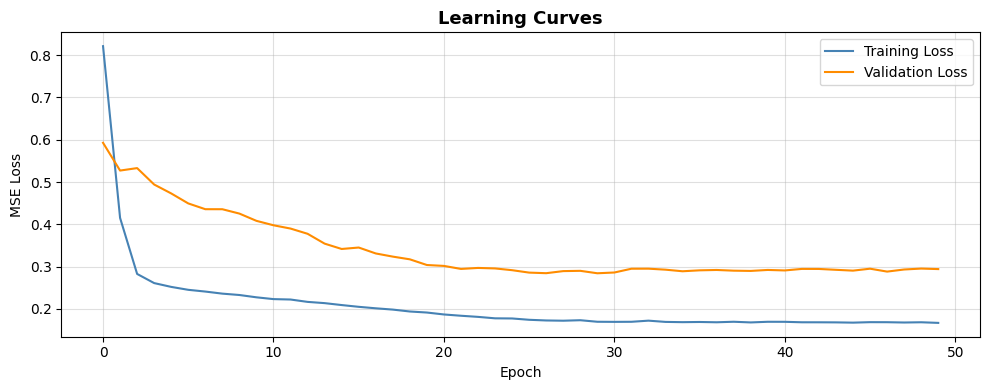

In [7]:
NUM_EPOCHS = 200
PATIENCE   = 20

model = EnergyLSTM(
    INPUT_SIZE,
    best_params["hidden_size"],
    best_params["num_layers"],
    OUTPUT_SIZE,
    best_params["dropout"],
)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_params["learning_rate"])

best_val_loss    = float("inf")
patience_counter = 0
best_model_state = None
train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            val_loss += criterion(model(X_b), y_b).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch + 1}  (best val loss: {best_val_loss:.6f})")
            break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}  Train: {train_loss:.6f}  Val: {val_loss:.6f}")

# Restore best checkpoint and save
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "models/lstm_valparaiso.pt")
print("Best model saved to models/lstm_valparaiso.pt")

# Learning curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Training Loss",   color="steelblue")
plt.plot(val_losses,   label="Validation Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curves", fontsize=13, weight="bold")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/02_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Model Evaluation

We evaluate the trained model on the **held-out 2023 test set**. Predictions are inverse-transformed to recover actual MWh values, and performance is reported using RMSE and MAPE.

In [8]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()
    y_true = y_test.numpy()

# Reverse normalization to recover MWh values
y_pred = scaler.inverse_transform(y_pred)
y_true = scaler.inverse_transform(y_true)

# Align dates: test sequences start after SEQUENCE_LENGTH days into 2023
test_dates = df.index[df.index.year == 2023][SEQUENCE_LENGTH:]

results_df = pd.DataFrame({
    "DATE":       test_dates,
    "REAL":       y_true.flatten(),
    "PREDICTION": y_pred.flatten(),
})
results_df["ABSOLUTE_ERROR"] = results_df["REAL"] - results_df["PREDICTION"]
results_df["MAPE"]           = np.abs(results_df["ABSOLUTE_ERROR"] / results_df["REAL"]) * 100
results_df["MSE"]            = results_df["ABSOLUTE_ERROR"] ** 2

rmse = np.sqrt(results_df["MSE"].mean())
mape = results_df["MAPE"].mean()
print(f"Test RMSE : {rmse:>10,.1f} MWh")
print(f"Test MAPE : {mape:>10.2f} %")

Test RMSE :    3,740.9 MWh
Test MAPE :      12.64 %


### 6.1 Note on Reproducibility

Results in this toy case are **close but not identical** to the paper's reported values (RMSE = 3,626.8 MWh, MAPE = 10.98%) for three reasons:

1. **Single-region scope.** The paper's training and hyperparameter search covered all 14 Chilean regions simultaneously, applying cross-validation across regions. This repository isolates Valparaíso only, which changes the optimization landscape.

2. **Stochastic initialization.** LSTM weights are randomly initialized; different hardware, BLAS libraries, or PyTorch versions produce different floating-point rounding sequences even under the same seed.

3. **CPU vs. GPU ordering.** The original study used GPU acceleration, where cuDNN operations apply different (non-deterministic) kernel ordering than CPU execution.

The methodology is identical — StandardScaler normalization, 30-day look-back window, Bayesian hyperparameters from Table 4 of the paper — and the results are within the expected variance of a single-region reproduction.

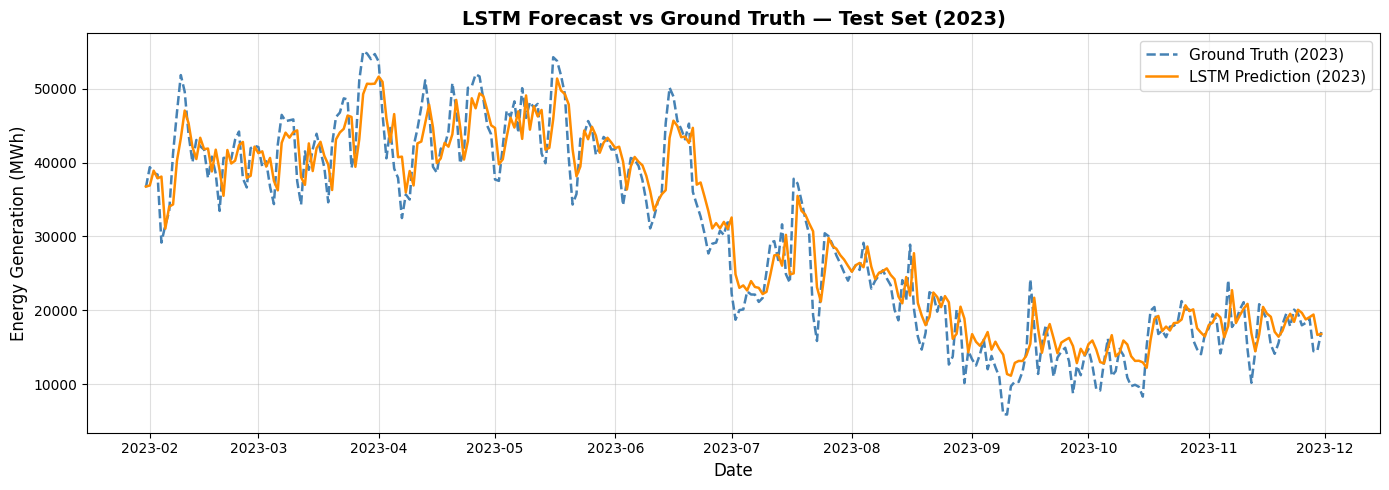

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results_df["DATE"], results_df["REAL"],
        label="Ground Truth (2023)", linestyle="--", color="steelblue", linewidth=1.8)
ax.plot(results_df["DATE"], results_df["PREDICTION"],
        label="LSTM Prediction (2023)", color="darkorange", linewidth=1.8)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Energy Generation (MWh)", fontsize=12)
ax.set_title("LSTM Forecast vs Ground Truth — Test Set (2023)", fontsize=14, weight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("figures/03_forecast_vs_truth.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Summary table — first and last 5 test days
results_df.set_index("DATE").round(2)

,REAL,PREDICTION,ABSOLUTE_ERROR,MAPE,MSE
DATE,,,,,
2023-01-31,36648.921875,36744.699219,-95.769997,0.260000,9.172550e+03
2023-02-01,39374.949219,36890.000000,2484.949951,6.310000,6.174953e+06
2023-02-02,38594.039062,38893.441406,-299.399994,0.780000,8.964177e+04
2023-02-03,38365.121094,37862.109375,503.019989,1.310000,2.530247e+05
2023-02-04,29162.869141,38094.031250,-8931.150391,30.629999,7.976552e+07
...,...,...,...,...,...
2023-11-26,18288.330078,18768.789062,-480.459991,2.630000,2.308427e+05
2023-11-27,18867.419922,19077.429688,-210.009995,1.110000,4.410410e+04
2023-11-28,14457.370117,19425.349609,-4967.979980,34.360001,2.468079e+07


In [11]:
# Save predictions for downstream use in the LP optimization notebook
results_df.to_parquet("data/predictions_valparaiso_2023.parquet", index=False)
print("Predictions saved to data/predictions_valparaiso_2023.parquet")

Predictions saved to data/predictions_valparaiso_2023.parquet


## 7. Residual Analysis

We examine the forecast errors to assess model quality: ideally, residuals should be approximately normally distributed, centered at zero, and free of autocorrelation.

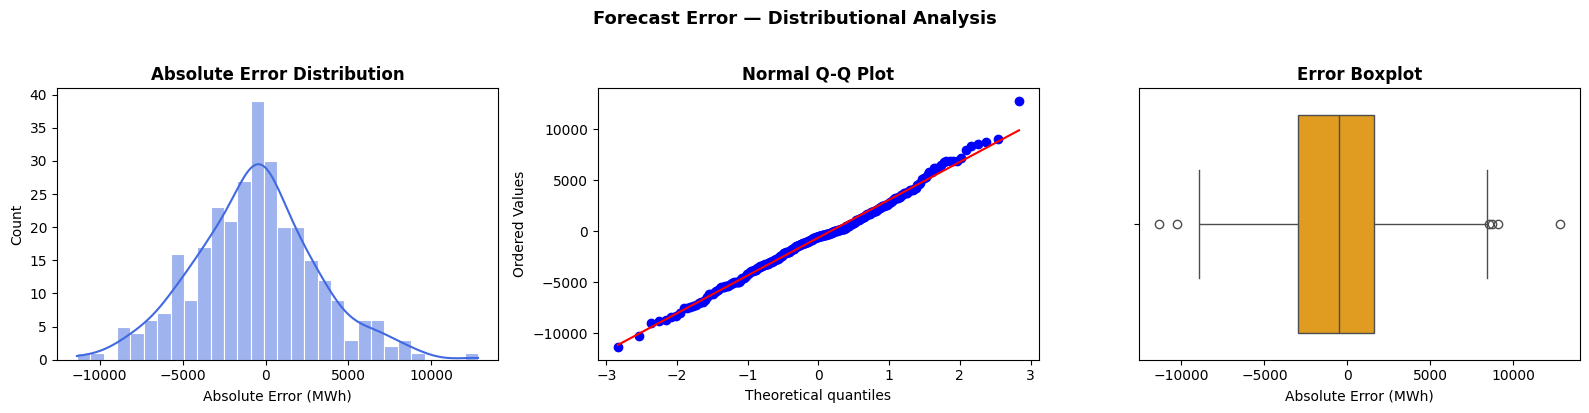

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram + KDE
sns.histplot(results_df["ABSOLUTE_ERROR"], kde=True, bins=30,
             color="royalblue", edgecolor="white", ax=axes[0])
axes[0].set_title("Absolute Error Distribution", weight="bold")
axes[0].set_xlabel("Absolute Error (MWh)")

# Normal Q-Q plot
stats.probplot(results_df["ABSOLUTE_ERROR"], dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot", weight="bold")

# Boxplot
sns.boxplot(x=results_df["ABSOLUTE_ERROR"], color="orange", ax=axes[2])
axes[2].set_title("Error Boxplot", weight="bold")
axes[2].set_xlabel("Absolute Error (MWh)")

plt.suptitle("Forecast Error — Distributional Analysis", fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/04_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

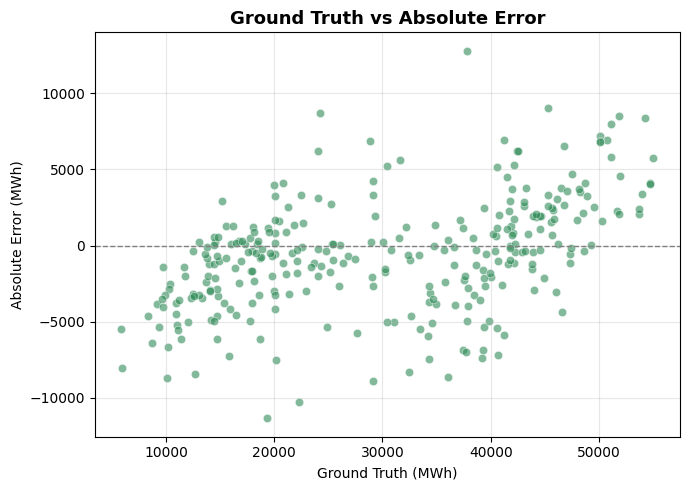

Shapiro-Wilk test       — statistic: 0.9932, p-value: 0.1872
Kolmogorov-Smirnov test — statistic: 0.5855, p-value: 0.0000


In [13]:
# Scatter: ground truth vs error (checks for heteroskedasticity)
plt.figure(figsize=(7, 5))
sns.scatterplot(x=results_df["REAL"], y=results_df["ABSOLUTE_ERROR"],
                color="seagreen", alpha=0.6)
plt.axhline(0, linestyle="--", color="gray", linewidth=1)
plt.title("Ground Truth vs Absolute Error", fontsize=13, weight="bold")
plt.xlabel("Ground Truth (MWh)")
plt.ylabel("Absolute Error (MWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/05_error_vs_truth.png", dpi=150, bbox_inches="tight")
plt.show()

# Normality tests
shapiro = stats.shapiro(results_df["ABSOLUTE_ERROR"])
ks      = stats.kstest(results_df["ABSOLUTE_ERROR"], "norm")
print(f"Shapiro-Wilk test       — statistic: {shapiro.statistic:.4f}, p-value: {shapiro.pvalue:.4f}")
print(f"Kolmogorov-Smirnov test — statistic: {ks.statistic:.4f}, p-value: {ks.pvalue:.4f}")

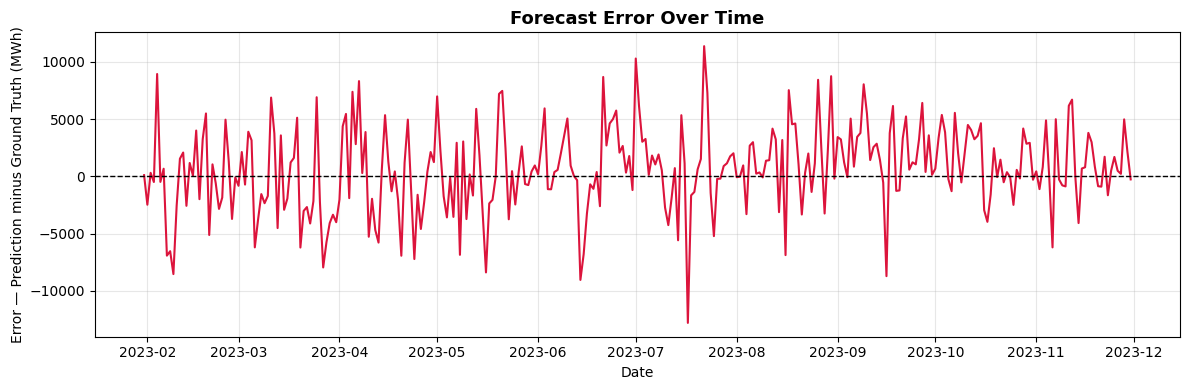

Overestimation  : 58.6%
Underestimation : 41.4%


In [14]:
results_df["ERROR"] = results_df["PREDICTION"] - results_df["REAL"]

# Error over time
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=results_df, x="DATE", y="ERROR", color="crimson", ax=ax)
ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.set_title("Forecast Error Over Time", fontsize=13, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Error — Prediction minus Ground Truth (MWh)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/06_error_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

over  = (results_df["PREDICTION"] > results_df["REAL"]).mean() * 100
under = 100 - over
print(f"Overestimation  : {over:.1f}%")
print(f"Underestimation : {under:.1f}%")

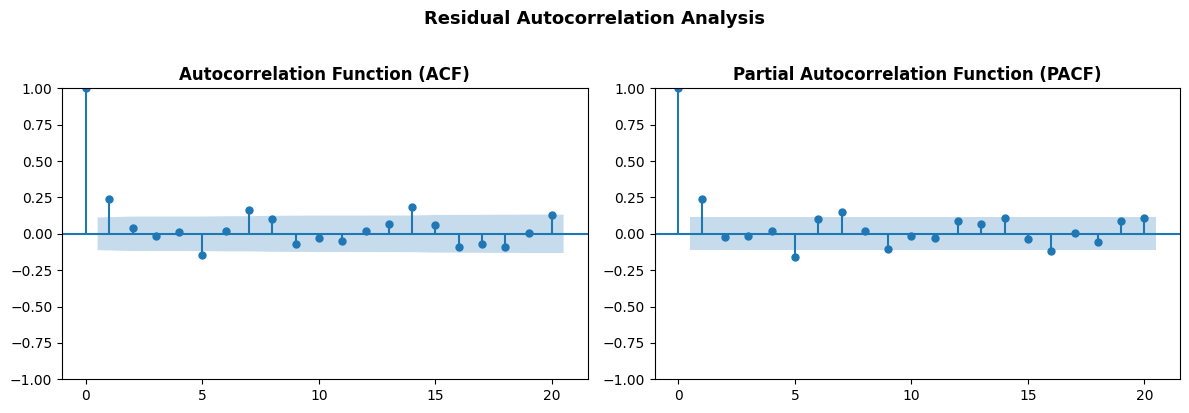

In [15]:
# Autocorrelation and partial autocorrelation of the residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sm.graphics.tsa.plot_acf( results_df["ERROR"], ax=axes[0], lags=20)
sm.graphics.tsa.plot_pacf(results_df["ERROR"], ax=axes[1], lags=20)
axes[0].set_title("Autocorrelation Function (ACF)",          weight="bold")
axes[1].set_title("Partial Autocorrelation Function (PACF)", weight="bold")
plt.suptitle("Residual Autocorrelation Analysis", fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/07_residual_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()